Gender Distribution Analysis 

Question: How does author gender distribution vary across book categories, and does gender composition correlate with pricing?

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

In [2]:
# Connect to the DuckDB database 
con = duckdb.connect('amazon_books.ddb')

In [3]:
# Cell 2: Load Data with Strategic Filtering
query = """
WITH book_counts AS (
    SELECT 
        b.primary_category,
        COUNT(*) as total_books,
        COUNT(CASE WHEN ag.inferred_gender IS NOT NULL THEN 1 END) as known_gender_books
    FROM books b
    LEFT JOIN reviews r ON b.Title=r.Title
    LEFT JOIN author_genders ag ON b.author_first_name = ag.author_first_name
    WHERE r.Price IS NOT NULL 
        AND b.primary_category IS NOT NULL
        AND b.Year BETWEEN 1900 AND 2020
    GROUP BY b.primary_category
    HAVING COUNT(*) >= 15  -- Only categories with at least 15 books total
),
filtered_books AS (
    SELECT 
        b.Title,
        b.primary_category,
        r.Price,
        b.author_first_name,
        COALESCE(ag.inferred_gender, 'unknown') as gender,
        ag.gender_confidence
    FROM books b
    LEFT JOIN reviews r ON b.Title=r.Title
    LEFT JOIN author_genders ag ON b.author_first_name = ag.author_first_name
    INNER JOIN book_counts bc ON b.primary_category = bc.primary_category
    WHERE r.Price IS NOT NULL 
        AND b.primary_category IS NOT NULL
        AND b.Year BETWEEN 1900 AND 2020
)
SELECT * FROM filtered_books
"""

df = con.execute(query).fetchdf()
print(f"Loaded {len(df):,} book records from categories with ≥15 books.")
print(f"Gender distribution:\n{df['gender'].value_counts(normalize=True).round(3) * 100}%")
print(f"\nNumber of categories: {df['primary_category'].nunique()}")
print("\nFirst few rows:")
print(df.head())

Loaded 377,171 book records from categories with ≥15 books.
Gender distribution:
gender
unknown    68.4
male       26.7
female      4.9
Name: proportion, dtype: float64%

Number of categories: 400

First few rows:
                                   Title           primary_category  Price  \
0  Wonderful Worship in Smaller Churches                   Religion  19.40   
1  Wonderful Worship in Smaller Churches                   Religion  19.40   
2  Wonderful Worship in Smaller Churches                   Religion  19.40   
3  Wonderful Worship in Smaller Churches                   Religion  19.40   
4               Saint Hyacinth of Poland  Biography & Autobiography  13.95   

  author_first_name  gender  gender_confidence  
0             David    male               1.00  
1             David    male               1.00  
2             David    male               1.00  
3             David    male               1.00  
4              Mary  female               0.99  


In [4]:
con.close()

In [5]:
# Create Focused Dataset for Core Analysis
# Focus on books where gender is known
df_known = df[df['gender'].isin(['male', 'female'])].copy()

# Remove extreme price outliers (top 1%)
price_q99 = df_known['Price'].quantile(0.99)
df_clean = df_known[df_known['Price'] <= price_q99].copy()

print(f"✅ Clean dataset for analysis: {len(df_clean):,} books")
print(f"Categories remaining: {df_clean['primary_category'].nunique()}")
print(f"Gender split: {df_clean['gender'].value_counts().to_dict()}")

✅ Clean dataset for analysis: 117,992 books
Categories remaining: 224
Gender split: {'male': 99763, 'female': 18229}


In [6]:
# Top 10 Most Gender-Balanced Categories
# Calculate gender ratio per category
category_stats = df_clean.groupby('primary_category').agg({
    'Price': 'count',
    'gender': lambda x: (x == 'female').sum() / len(x) * 100  # Female percentage
}).rename(columns={'Price': 'book_count', 'gender': 'female_pct'}).reset_index()

# Filter for meaningful sample sizes (at least 10 books per category)
category_stats = category_stats[category_stats['book_count'] >= 10].copy()

# Find most balanced categories (closest to 50%)
category_stats['balance_score'] = abs(category_stats['female_pct'] - 50)

# For balanced categories: sort by book_count DESCENDING, then balance_score ASCENDING
most_balanced = category_stats.nsmallest(20, 'balance_score')  # Get more than 10 for sorting
most_balanced = most_balanced.sort_values(['book_count', 'balance_score'], ascending=[False, True]).head(10)

# Find most extreme categories
# For male-dominated: sort by female_pct ASCENDING, then book_count DESCENDING
most_male_dominated = category_stats.nsmallest(20, 'female_pct')
most_male_dominated = most_male_dominated.sort_values(['female_pct', 'book_count'], ascending=[True, False]).head(10)

# For female-dominated: sort by female_pct DESCENDING, then book_count DESCENDING
most_female_dominated = category_stats.nlargest(20, 'female_pct')
most_female_dominated = most_female_dominated.sort_values(['female_pct', 'book_count'], ascending=[False, False]).head(10)

print("Most Gender-Balanced Categories (closest to 50/50):")
print("Sorted by: Book Count (desc), then Balance Score")
print(most_balanced[['primary_category', 'female_pct', 'book_count']].to_string(index=False))

print(f"\nMost Male-Dominated Categories:")
print("Sorted by: Female % (asc), then Book Count (desc)")
print(most_male_dominated[['primary_category', 'female_pct', 'book_count']].to_string(index=False))

print(f"\nMost Female-Dominated Categories:")
print("Sorted by: Female % (desc), then Book Count (desc)")
print(most_female_dominated[['primary_category', 'female_pct', 'book_count']].to_string(index=False))

Most Gender-Balanced Categories (closest to 50/50):
Sorted by: Book Count (desc), then Balance Score
           primary_category  female_pct  book_count
                    Fiction   25.306981       23780
           Juvenile Fiction   28.065242        5334
     Family & Relationships   24.932331        3325
           Health & Fitness   20.406091        2955
                    Cooking   20.122526        2122
        Body, Mind & Spirit   38.746298        2026
Language Arts & Disciplines   34.353741        1764
                  Self-Help   23.575130        1544
        Juvenile Nonfiction   25.213395        1523
                 True Crime   22.118743         859

Most Male-Dominated Categories:
Sorted by: Female % (asc), then Book Count (desc)
        primary_category  female_pct  book_count
       Books and reading         0.0         777
                Behavior         0.0         181
      Arthurian romances         0.0          73
                  Canada         0.0          71

In [7]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("colorblind")
%matplotlib inline

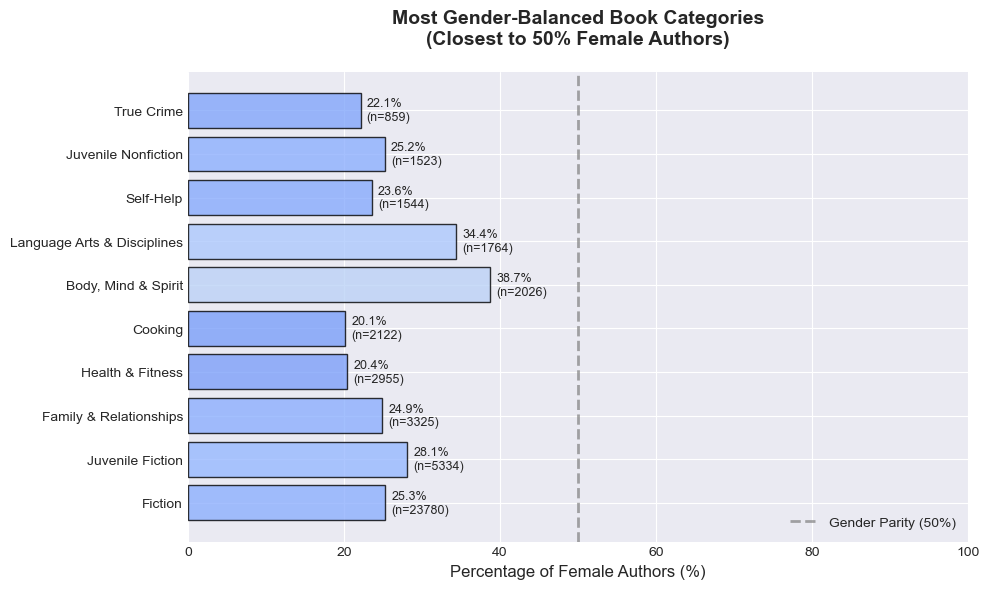

In [8]:
# Visualization 1 - Top Balanced Categories (Clean Horizontal Bar)
plt.figure(figsize=(10, 6))

# Create color gradient based on female percentage
colors = plt.cm.coolwarm(most_balanced['female_pct'] / 100)

bars = plt.barh(most_balanced['primary_category'], most_balanced['female_pct'], 
                color=colors, edgecolor='black', alpha=0.8)

plt.xlabel('Percentage of Female Authors (%)', fontsize=12)
plt.title('Most Gender-Balanced Book Categories\n(Closest to 50% Female Authors)', 
          fontsize=14, pad=20, fontweight='bold')
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.7, linewidth=2, label='Gender Parity (50%)')

# Add value labels
for bar, count in zip(bars, most_balanced['book_count']):
    width = bar.get_width()
    plt.text(width + 0.8, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%\n(n={count})', 
             ha='left', va='center', fontsize=9)

plt.xlim(0, 100)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [9]:
category_price_gaps = []
for category in df_clean['primary_category'].unique():
    cat_data = df_clean[df_clean['primary_category'] == category]
    
    # Check if both genders present with sufficient data
    male_in_cat = cat_data[cat_data['gender'] == 'male']
    female_in_cat = cat_data[cat_data['gender'] == 'female']
    
    if len(male_in_cat) >= 5 and len(female_in_cat) >= 5:
        male_median = male_in_cat['Price'].median()
        female_median = female_in_cat['Price'].median()
        price_diff = male_median - female_median
        
        # Statistical test for this category
        if len(male_in_cat) >= 10 and len(female_in_cat) >= 10:
            u_stat_cat, p_val_cat = stats.mannwhitneyu(
                male_in_cat['Price'], 
                female_in_cat['Price'],
                alternative='two-sided'
            )
            significant = p_val_cat < 0.05
        else:
            significant = None  # Not enough data for reliable test
        
        category_price_gaps.append({
            'Category': category,
            'Male_Count': len(male_in_cat),
            'Female_Count': len(female_in_cat),
            'Male_Median': male_median,
            'Female_Median': female_median,
            'Price_Diff': price_diff,
            'P_Value': p_val_cat if 'p_val_cat' in locals() else None,
            'Significant': significant
        })

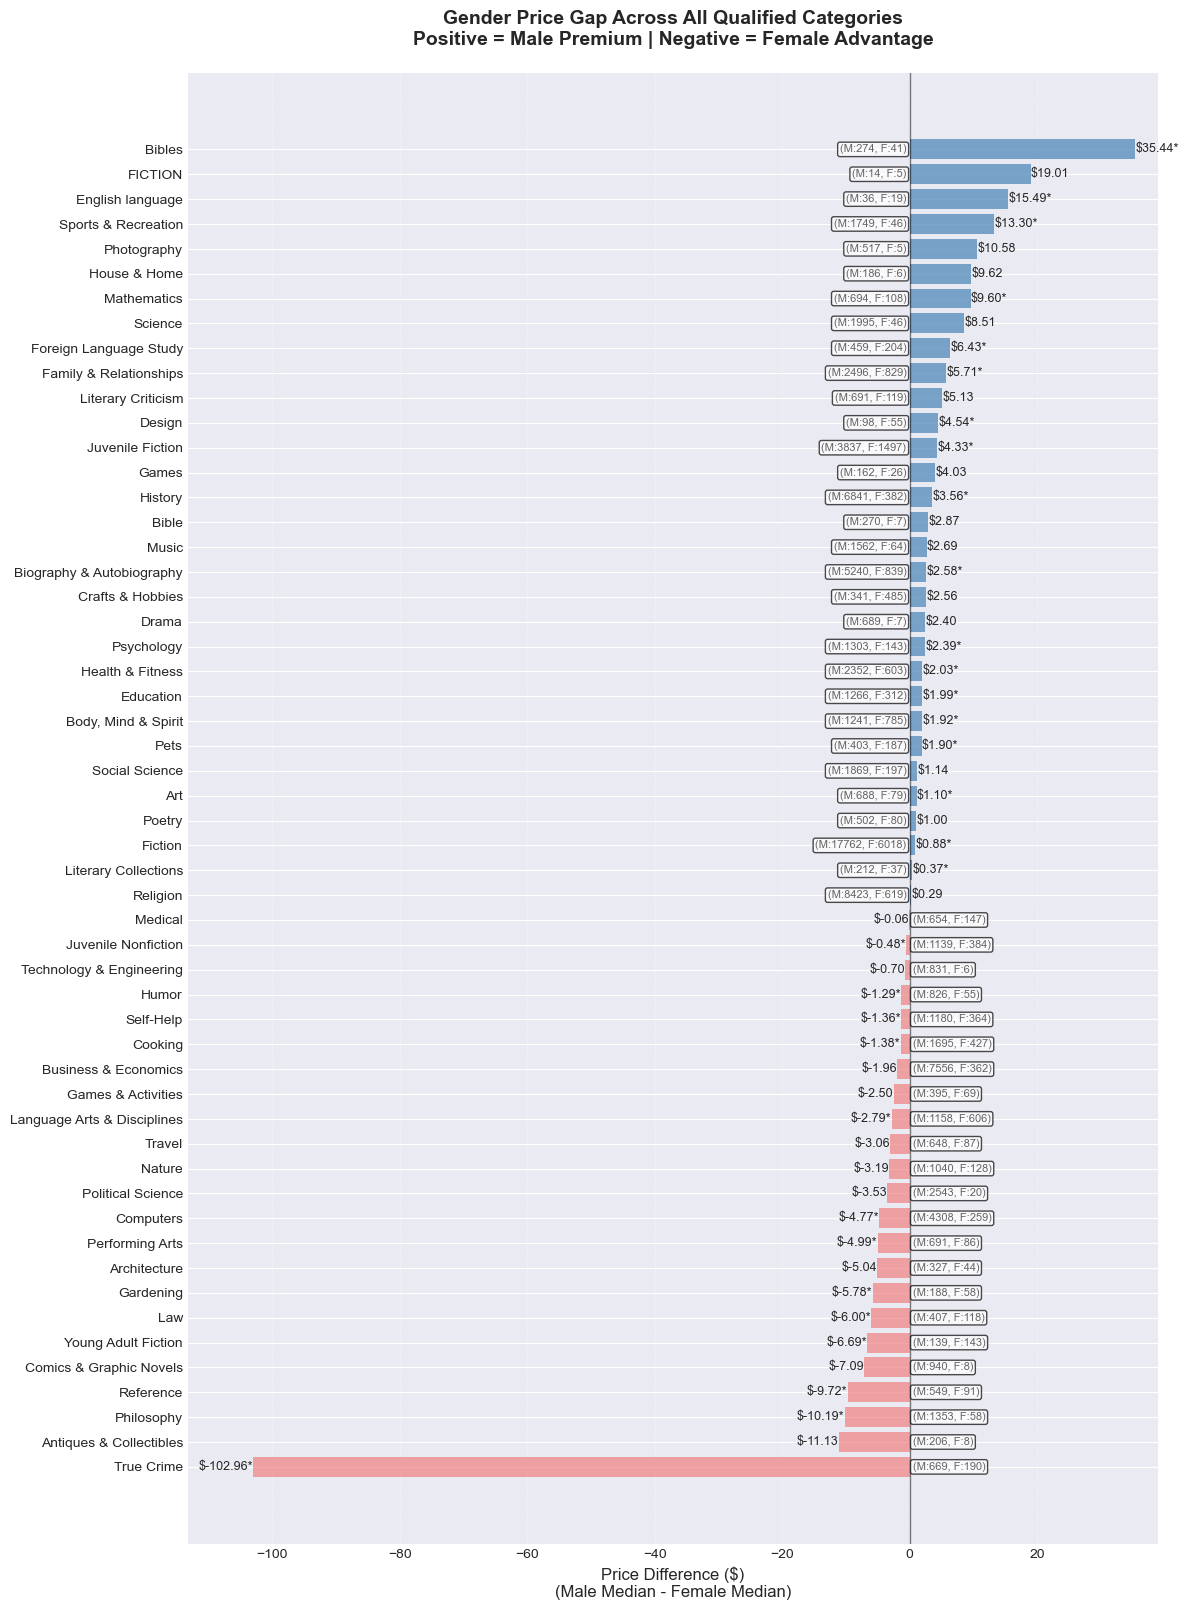

In [10]:
# Visualization - Price Gaps Across All Qualified Categories
if category_price_gaps:
    # Prepare data for visualization
    vis_df = pd.DataFrame(category_price_gaps)
    vis_df = vis_df.sort_values('Price_Diff', ascending=True)  # Sort for better visualization
    
    # Create the visualization
    plt.figure(figsize=(12, max(6, len(vis_df) * 0.3)))  # Dynamic height based on number of categories
    
    # Create horizontal bars
    colors = ['steelblue' if x > 0 else 'lightcoral' for x in vis_df['Price_Diff']]
    bars = plt.barh(vis_df['Category'], vis_df['Price_Diff'], color=colors, alpha=0.7)
    
    # Add vertical line at 0
    plt.axvline(x=0, color='black', linewidth=1, alpha=0.5)
    
    # Customize appearance
    plt.xlabel('Price Difference ($)\n(Male Median - Female Median)', fontsize=12)
    plt.title('Gender Price Gap Across All Qualified Categories\n' +
              'Positive = Male Premium | Negative = Female Advantage', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Add value labels and significance markers
    for i, (bar, row) in enumerate(zip(bars, vis_df.itertuples())):
        width = bar.get_width()
        
        # Position label based on bar direction
        if width >= 0:
            label_x = width + 0.05
            ha = 'left'
        else:
            label_x = width - 0.05
            ha = 'right'
        
        # Create label with price and sample size
        label = f'${width:.2f}'
        if row.Significant == True:
            label += '*'
        
        plt.text(label_x, bar.get_y() + bar.get_height()/2, 
                label, ha=ha, va='center', fontsize=9)
        
        # Add sample size below category name
        plt.text(-0.5 if width >= 0 else 0.5,  # Position near zero line
                bar.get_y() + bar.get_height()/2,
                f'(M:{row.Male_Count}, F:{row.Female_Count})',
                ha='right' if width >= 0 else 'left',
                va='center', fontsize=8, alpha=0.7, 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    
    # Adjust limits with some padding
    x_min = vis_df['Price_Diff'].min() * 1.1
    x_max = vis_df['Price_Diff'].max() * 1.1
    plt.xlim(min(x_min, -1), max(x_max, 1))
    
    plt.grid(True, alpha=0.3, axis='x', linestyle='--')
    plt.tight_layout()
    plt.show()
    

In [11]:
# Category-Specific Price Analysis (Focused on Key Categories)

interesting_categories = []
for cat in ['Technology & Engineering','Mathematics', 'Medical', 'Science', 'Language Arts & Disciplines', 'Law', 'Literary Criticism', 'Social Science', 'Psychology', 'Computers' ]:
    if cat in df_clean['primary_category'].unique():
        interesting_categories.append(cat)

# Analyze price differences within these categories
category_results = []
for cat in interesting_categories:
    cat_data = df_clean[df_clean['primary_category'] == cat]
    
    if len(cat_data['gender'].unique()) == 2:  # Both genders present
        male_price = cat_data[cat_data['gender'] == 'male']['Price']
        female_price = cat_data[cat_data['gender'] == 'female']['Price']
        
        if len(male_price) >= 5 and len(female_price) >= 5:
            u_stat, p_val = stats.mannwhitneyu(male_price, female_price)
            
            category_results.append({
                'Category': cat,
                'Male_Count': len(male_price),
                'Female_Count': len(female_price),
                'Male_Median': male_price.median(),
                'Female_Median': female_price.median(),
                'Price_Diff': male_price.median() - female_price.median(),
                'P_Value': p_val,
                'Significant': p_val < 0.05
            })

results_df = pd.DataFrame(category_results).sort_values('Price_Diff', ascending=False)
print("Category-Specific Price Analysis (TOP 10 MOST EXPENSIVE CATEGORIES)")
print("=" * 50)
print(results_df.round(3).to_string(index=False))

Category-Specific Price Analysis (TOP 10 MOST EXPENSIVE CATEGORIES)
                   Category  Male_Count  Female_Count  Male_Median  Female_Median  Price_Diff  P_Value  Significant
                Mathematics         694           108        19.59           9.99        9.60    0.000         True
                    Science        1995            46        12.50           3.99        8.51    0.382        False
         Literary Criticism         691           119        17.90          12.77        5.13    0.374        False
                 Psychology        1303           143        14.79          12.40        2.39    0.040         True
             Social Science        1869           197        18.09          16.95        1.14    0.249        False
                    Medical         654           147        17.15          17.21       -0.06    0.919        False
   Technology & Engineering         831             6        14.79          15.49       -0.70    0.173        False
Lang

/var/folders/3t/dg_64gps7270wgpfzs5m83bw0000gp/T/ipykernel_1136/3656794698.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Category'], rotation=45, ha='right')


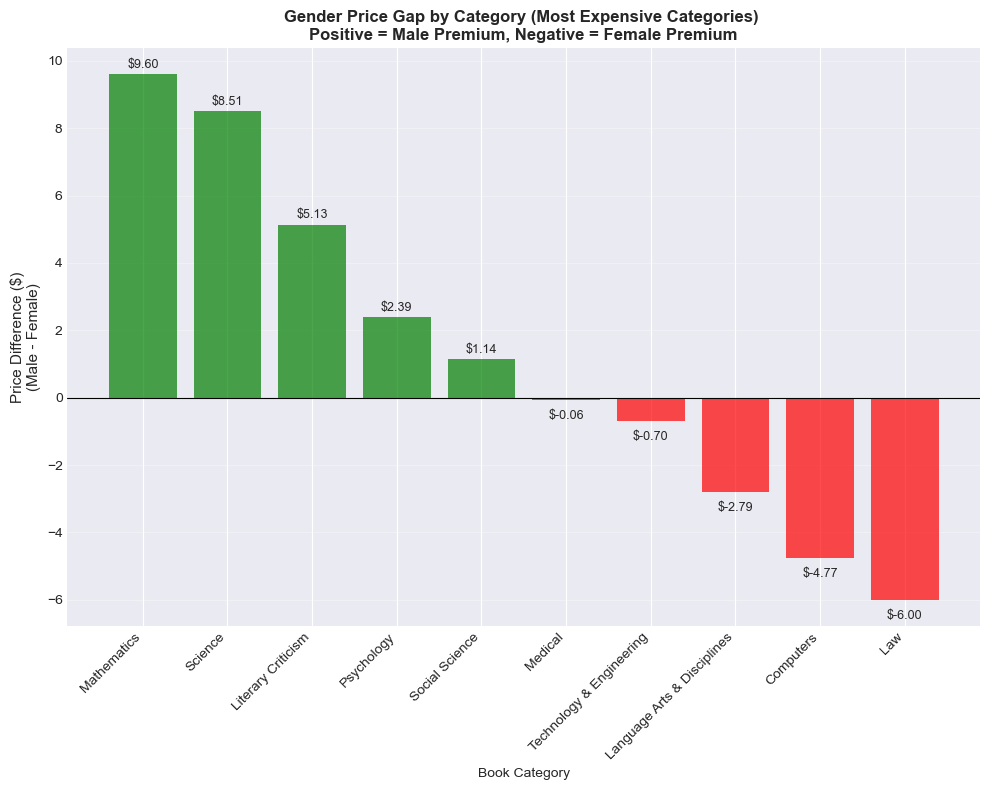

In [12]:
# Visualization 3 - Category-Specific Price Comparison (Most Expensive Categories)
fig, ax = plt.subplots(figsize=(10, 8))

# Plot: Price differences (premium)
colors = ['green' if x > 0 else 'red' for x in results_df['Price_Diff']]
bars = ax.bar(results_df['Category'], results_df['Price_Diff'], color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Book Category')
ax.set_ylabel('Price Difference ($)\n(Male - Female)', fontsize=11)
ax.set_title('Gender Price Gap by Category (Most Expensive Categories) \nPositive = Male Premium, Negative = Female Premium', 
            fontweight='bold')
ax.set_xticklabels(results_df['Category'], rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    va_position = 'bottom' if height >= 0 else 'top'
    y_offset = 0.1 if height >= 0 else -0.3
    ax.text(bar.get_x() + bar.get_width()/2, 
            height + y_offset,
            f'${height:.2f}', ha='center', va=va_position, fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
# Category-Specific Price Analysis (Focused on Least Expensive Categories)

least_exp_categories = []
for cat in ['Crafts & Hobbies','Body, Mind & Spirit', 'Travel', 'Young Adult Fiction', 'Juvenile Nonfiction', 'Self-Help', 'Comics & Graphic Novels', 'Humor', 'Juvenile Fiction', 'Pets' ]:
    if cat in df_clean['primary_category'].unique():
        least_exp_categories.append(cat)

# Analyze price differences within these categories
least_category_results = []
for cat in least_exp_categories:
    cat_data = df_clean[df_clean['primary_category'] == cat]
    
    if len(cat_data['gender'].unique()) == 2:  # Both genders present
        male_price = cat_data[cat_data['gender'] == 'male']['Price']
        female_price = cat_data[cat_data['gender'] == 'female']['Price']
        
        if len(male_price) >= 5 and len(female_price) >= 5:
            u_stat, p_val = stats.mannwhitneyu(male_price, female_price)
            
            least_category_results.append({
                'Category': cat,
                'Male_Count': len(male_price),
                'Female_Count': len(female_price),
                'Male_Median': male_price.median(),
                'Female_Median': female_price.median(),
                'Price_Diff': male_price.median() - female_price.median(),
                'P_Value': p_val,
                'Significant': p_val < 0.05
            })

least_exp_results_df = pd.DataFrame(least_category_results).sort_values('Price_Diff', ascending=False)
print("Category-Specific Price Analysis (TOP 10 LEAST EXPENSIVE CATEGORIES)")
print("=" * 50)
print(least_exp_results_df.round(3).to_string(index=False))

Category-Specific Price Analysis (TOP 10 LEAST EXPENSIVE CATEGORIES)
               Category  Male_Count  Female_Count  Male_Median  Female_Median  Price_Diff  P_Value  Significant
       Juvenile Fiction        3837          1497        14.03          9.700       4.330    0.000         True
       Crafts & Hobbies         341           485        14.93         12.370       2.560    0.501        False
    Body, Mind & Spirit        1241           785        13.31         11.390       1.920    0.000         True
                   Pets         403           187         4.39          2.490       1.900    0.000         True
    Juvenile Nonfiction        1139           384        10.39         10.870      -0.480    0.000         True
                  Humor         826            55         9.95         11.240      -1.290    0.000         True
              Self-Help        1180           364        10.85         12.205      -1.355    0.000         True
                 Travel         648

/var/folders/3t/dg_64gps7270wgpfzs5m83bw0000gp/T/ipykernel_1136/2355602458.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(least_exp_results_df['Category'], rotation=45, ha='right')


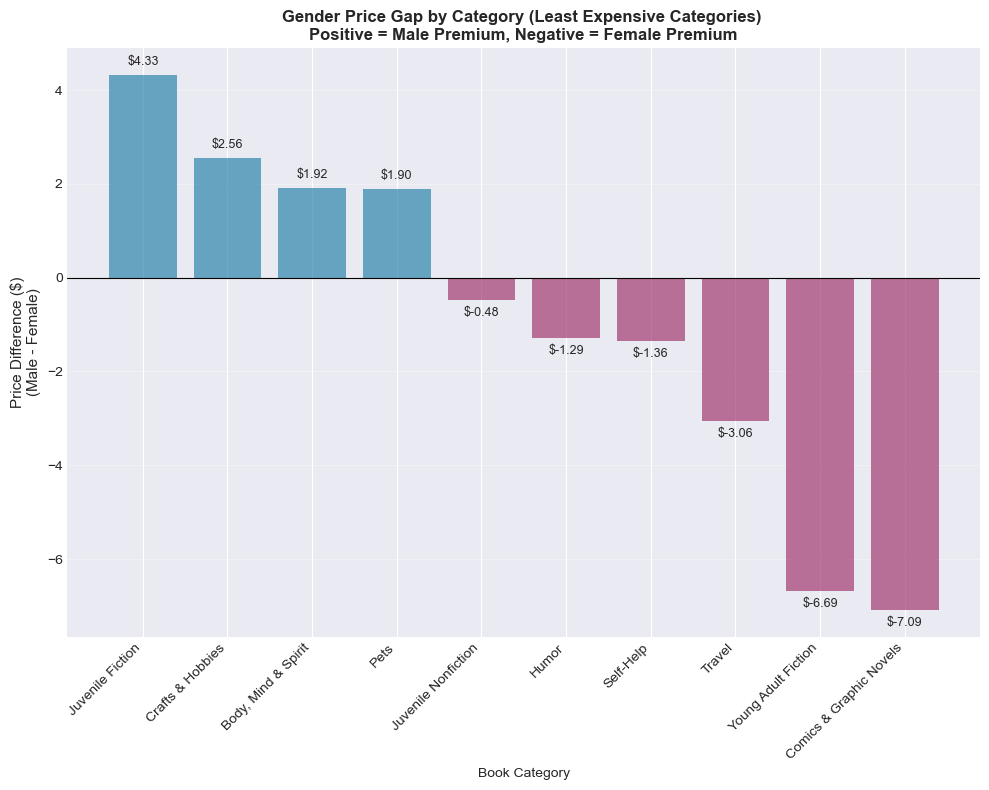

In [14]:
# Visualization 4 - Category-Specific Price Comparison (Least Expensive Categories)
fig, ax = plt.subplots(figsize=(10, 8))

# Plot: Price differences (premium) - Fixed color assignment
colors = ['#2E86AB' if x > 0 else '#A23B72' for x in least_exp_results_df['Price_Diff']]  # Blue for male premium, Purple for female premium
bars = ax.bar(least_exp_results_df['Category'], least_exp_results_df['Price_Diff'], color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Book Category')
ax.set_ylabel('Price Difference ($)\n(Male - Female)', fontsize=11)
ax.set_title('Gender Price Gap by Category (Least Expensive Categories) \nPositive = Male Premium, Negative = Female Premium', 
                fontweight='bold')
ax.set_xticklabels(least_exp_results_df['Category'], rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    va_position = 'bottom' if height >= 0 else 'top'
    y_offset = 0.02 * max(abs(least_exp_results_df['Price_Diff'])) if height >= 0 else -0.02 * max(abs(least_exp_results_df['Price_Diff']))
    ax.text(bar.get_x() + bar.get_width()/2, 
            height + y_offset,
            f'${height:.2f}', ha='center', va=va_position, fontsize=9)

plt.tight_layout()
plt.show()